# Assignment: Pandas Groupby with Hurricane Data

In [4]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [23]:
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716165 entries, 0 to 716164
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   SID       716165 non-null  object        
 1   SEASON    716165 non-null  int64         
 2   NUMBER    716165 non-null  int64         
 3   BASIN     716165 non-null  object        
 4   SUBBASIN  716165 non-null  object        
 5   NAME      390393 non-null  object        
 6   ISO_TIME  716165 non-null  datetime64[ns]
 7   NATURE    716165 non-null  object        
 8   LAT       716165 non-null  float64       
 9   LON       716165 non-null  float64       
 10  WMO_WIND  157570 non-null  float64       
 11  WMO_PRES  160275 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(5)
memory usage: 65.6+ MB


In [17]:
df

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
0,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 03:00:00,NR,10.9000,80.3000,NaN,NaN
1,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 06:00:00,NR,10.8709,79.8265,NaN,NaN
2,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 09:00:00,NR,10.8431,79.3524,NaN,NaN
3,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 12:00:00,NR,10.8188,78.8772,NaN,NaN
4,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 15:00:00,NR,10.8000,78.4000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN


In [13]:
gb = df.groupby('BASIN')
gb.get_group('NA')

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
562,1851175N26270,1851,5,NA,GM,NaN,1851-06-23 12:00:00,TS,26.1000,-90.4000,NaN,NaN
563,1851175N26270,1851,5,NA,GM,NaN,1851-06-23 15:00:00,TS,26.2001,-90.6999,NaN,NaN
564,1851175N26270,1851,5,NA,GM,NaN,1851-06-23 18:00:00,TS,26.3000,-91.0000,NaN,NaN
565,1851175N26270,1851,5,NA,GM,NaN,1851-06-23 21:00:00,TS,26.3999,-91.3001,NaN,NaN
566,1851175N26270,1851,5,NA,GM,NaN,1851-06-24 00:00:00,TS,26.5000,-91.6000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
715088,2023321N15278,2023,79,NA,CS,NaN,2023-11-17 12:00:00,NR,17.0364,-79.8000,NaN,NaN
715089,2023321N15278,2023,79,NA,CS,NaN,2023-11-17 15:00:00,NR,17.5021,-79.1718,NaN,NaN
715090,2023321N15278,2023,79,NA,CS,NaN,2023-11-17 18:00:00,NR,18.0000,-78.5000,NaN,NaN
715091,2023321N15278,2023,79,NA,CS,NaN,2023-11-17 21:00:00,NR,18.5966,-77.8436,NaN,NaN


In [16]:
gb.get_group('NA').count()

SID         126392
SEASON      126392
NUMBER      126392
BASIN       126392
SUBBASIN    126392
NAME         53334
ISO_TIME    126392
NATURE      126392
LAT         126392
LON         126392
WMO_WIND     53955
WMO_PRES     22975
dtype: int64

####  How many rows does this dataset have? How many North Atlantic hurricanes are in this dataset?
Basin Key: (NI - North Indian, SI - South Indian, WP - Western Pacific, SP - Southern Pacific, EP - Eastern Pacific, NA - North Atlantic)

##### There are 716165 rows in the dataset, and 126392 North Atlantic hurricanes

## 1) Get the unique values of the BASIN, SUBBASIN, and NATURE columns

In [18]:
df['BASIN'].unique()

array(['NI', 'SI', 'NA', 'EP', 'WP', 'SP', 'SA'], dtype=object)

In [19]:
df['SUBBASIN'].unique()

array(['BB', 'AS', 'MM', 'GM', 'NA', 'CS', 'WA', 'EA', 'CP'], dtype=object)

In [20]:
df['NATURE'].unique()

array(['NR', 'TS', 'ET', 'SS', 'MX', 'DS'], dtype=object)

## 2) Rename the WMO_WIND and WMO_PRES columns to WIND and PRES

In [34]:
df_r = df.rename(columns={'WMO_WIND':'WIND','WMO_PRES':'PRES'})

In [35]:
df_r.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716165 entries, 0 to 716164
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   SID       716165 non-null  object        
 1   SEASON    716165 non-null  int64         
 2   NUMBER    716165 non-null  int64         
 3   BASIN     716165 non-null  object        
 4   SUBBASIN  716165 non-null  object        
 5   NAME      390393 non-null  object        
 6   ISO_TIME  716165 non-null  datetime64[ns]
 7   NATURE    716165 non-null  object        
 8   LAT       716165 non-null  float64       
 9   LON       716165 non-null  float64       
 10  WIND      157570 non-null  float64       
 11  PRES      160275 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(5)
memory usage: 65.6+ MB


## 3) Get the 10 largest rows in the dataset by WIND
You will notice some names are repeated.

In [68]:
WIND_10 = df_r['WIND'].nlargest(10)
WIND_10

666142    185.0
666140    180.0
666144    180.0
427655    165.0
178210    160.0
178211    160.0
178213    160.0
482093    160.0
552477    160.0
605764    160.0
Name: WIND, dtype: float64

In [69]:
df_r.nlargest(10,'WIND')

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3,-105.6,185.0,872.0
666140,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 06:00:00,TS,16.5,-105.4,180.0,886.0
666144,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 18:00:00,TS,18.3,-105.3,180.0,878.0
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8,-86.4,165.0,899.0
178210,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 00:00:00,TS,24.6,-80.5,160.0,892.0
178211,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 02:00:00,TS,24.8,-80.8,160.0,892.0
178213,1935241N23291,1935,46,NA,GM,NaN,1935-09-03 06:00:00,TS,25.1,-81.1,160.0,NaN
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7,-83.8,160.0,888.0
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1,-109.6,160.0,902.0
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3,-82.8,160.0,882.0


## 4) Group the data on SID and get the 10 largest hurricanes by WIND

In [78]:
df_r.groupby('SID')['WIND'].max().nlargest(10)

SID
2015293N13266    185.0
1980214N11330    165.0
1935241N23291    160.0
1988253N12306    160.0
1997253N12255    160.0
2005289N18282    160.0
2019236N10314    160.0
1998295N12284    155.0
2005261N21290    155.0
2009288N07267    155.0
Name: WIND, dtype: float64

## 5) Make a bar chart of the wind speed of the 20 strongest-wind hurricanes
Use the name on the x-axis.

In [88]:
top_20 = df_r.sort_values('WIND',ascending= False).drop_duplicates('SID').head(20)
top_20

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3000,-105.60,185.0,872.0
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8000,-86.40,165.0,899.0
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7000,-83.80,160.0,888.0
689871,2019236N10314,2019,52,NA,NA,DORIAN,2019-09-01 18:00:00,TS,26.5000,-77.10,160.0,910.0
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3000,-82.80,160.0,882.0
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1000,-109.60,160.0,902.0
178213,1935241N23291,1935,46,NA,GM,NaN,1935-09-03 06:00:00,TS,25.1000,-81.10,160.0,NaN
676424,2017242N16333,2017,67,NA,CS,IRMA,2017-09-06 11:15:00,TS,18.1000,-63.10,155.0,914.0
605000,2005261N21290,2005,80,NA,GM,RITA,2005-09-22 06:00:00,TS,24.8000,-87.60,155.0,897.0
629245,2009288N07267,2009,82,EP,MM,RICK,2009-10-18 06:00:00,TS,15.1667,-106.60,155.0,906.0


In [106]:
top_20 = top_20.copy()
top_20['LABEL'] = (
    top_20['NAME'].fillna('N/A') + ' (' + top_20['SID'] + ')'
)
top_20  # Because there are two hurricanes do not have name. "SID+N/A or NAME"  = LABEL

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES,LABEL
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3000,-105.60,185.0,872.0,PATRICIA (2015293N13266)
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8000,-86.40,165.0,899.0,ALLEN (1980214N11330)
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7000,-83.80,160.0,888.0,GILBERT (1988253N12306)
689871,2019236N10314,2019,52,NA,NA,DORIAN,2019-09-01 18:00:00,TS,26.5000,-77.10,160.0,910.0,DORIAN (2019236N10314)
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3000,-82.80,160.0,882.0,WILMA (2005289N18282)
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1000,-109.60,160.0,902.0,LINDA (1997253N12255)
178213,1935241N23291,1935,46,NA,GM,N/A,1935-09-03 06:00:00,TS,25.1000,-81.10,160.0,NaN,N/A (1935241N23291)
676424,2017242N16333,2017,67,NA,CS,IRMA,2017-09-06 11:15:00,TS,18.1000,-63.10,155.0,914.0,IRMA (2017242N16333)
605000,2005261N21290,2005,80,NA,GM,RITA,2005-09-22 06:00:00,TS,24.8000,-87.60,155.0,897.0,RITA (2005261N21290)
629245,2009288N07267,2009,82,EP,MM,RICK,2009-10-18 06:00:00,TS,15.1667,-106.60,155.0,906.0,RICK (2009288N07267)


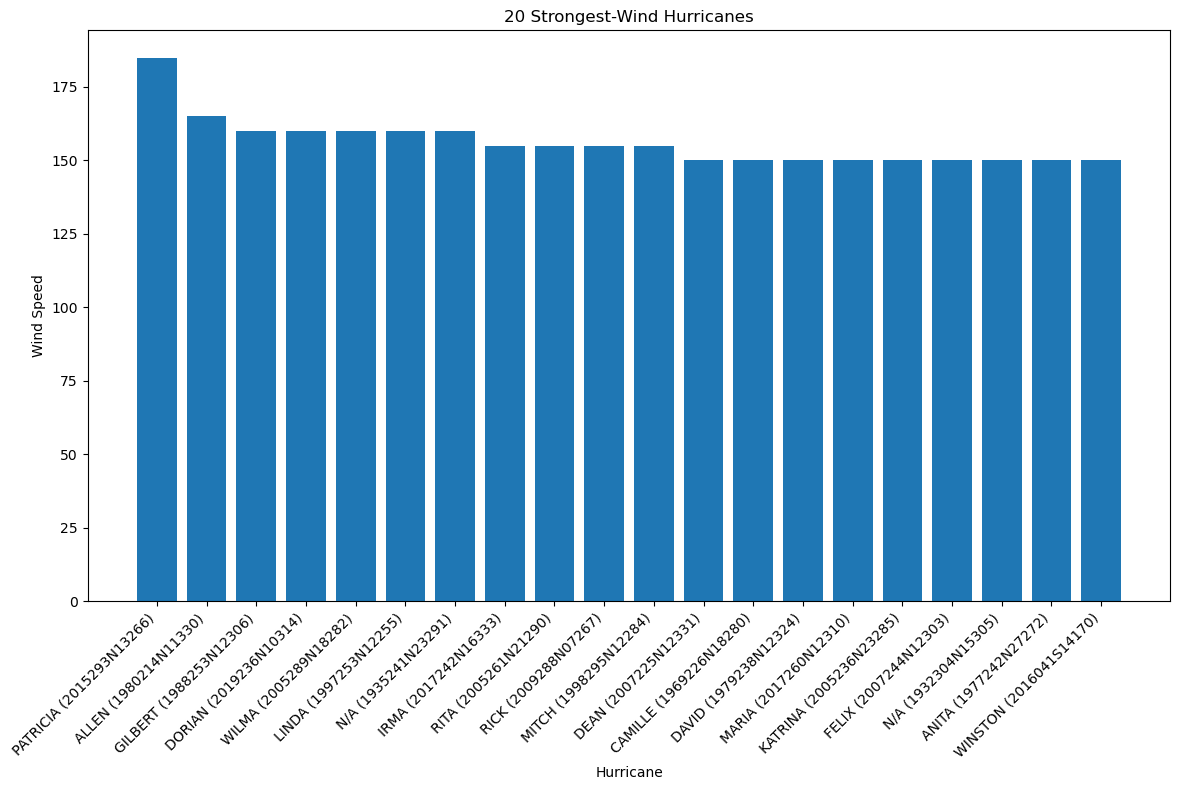

In [109]:
plt.figure(figsize=(12,8))
plt.bar(top_20['LABEL'],top_20['WIND'])
plt.xlabel('Hurricane')
plt.ylabel('Wind Speed')
plt.title('20 Strongest-Wind Hurricanes')
plt.xticks(rotation=45, ha='right')   # key line
plt.tight_layout()                    # prevents cutoff

## 6) Plot the count of all datapoints by Basin
as a bar chart

In [127]:
basin_counts = df_r['BASIN'].value_counts()

In [131]:
basin_count.head(10)

BASIN
WP    238485
SI    163710
NA    126392
SP     68233
EP     63434
NI     55792
SA       119
Name: count, dtype: int64

Text(0.5, 1.0, 'Count of Data Points by Basin')

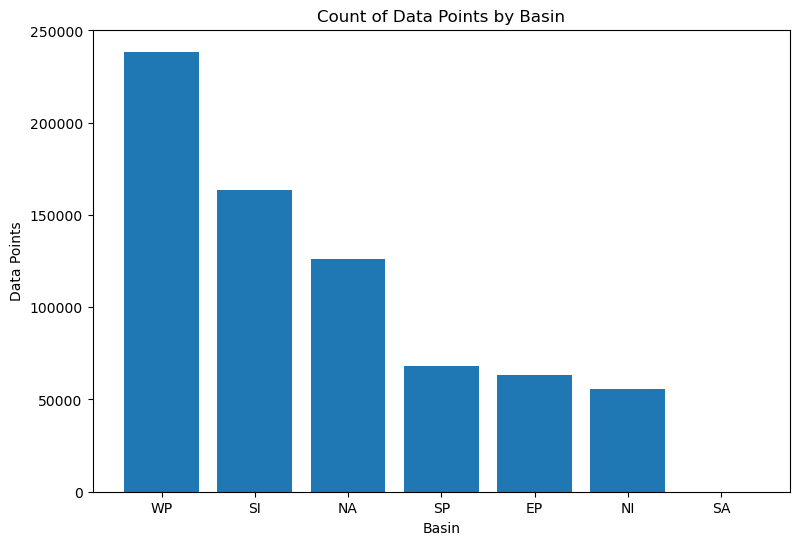

In [163]:
plt.figure(figsize=(9,6))
plt.bar(basin_counts.index,basin_counts.values)
plt.xlabel('Basin')
plt.ylabel('Data Points')
plt.title('Count of Data Points by Basin')

## 7) Plot the count of unique hurricanes by Basin
as a bar chart.

In [155]:
unique_h = df_r.drop_duplicates('SID')
unique_h

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
0,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 03:00:00,NR,10.9,80.3,NaN,NaN
65,1845336N10074,1845,1,NI,AS,NaN,1845-12-02 03:00:00,NR,10.0,74.3,NaN,NaN
90,1848011S09079,1848,1,SI,MM,NaN,1848-01-11 06:00:00,NR,-9.0,79.0,NaN,NaN
139,1848011S09080,1848,2,SI,MM,NaN,1848-01-11 06:00:00,NR,-8.6,79.8,NaN,NaN
228,1848011S15057,1848,3,SI,MM,NaN,1848-01-11 06:00:00,NR,-15.2,57.4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
716040,2024123S09045,2024,23,SI,MM,HIDAYA,2024-05-01 12:00:00,NR,-8.6,45.1,NaN,NaN
716065,2024138S09053,2024,24,SI,MM,IALY,2024-05-16 12:00:00,NR,-9.1,52.5,NaN,NaN
716114,2024141S02075,2024,25,SI,MM,NaN,2024-05-19 18:00:00,NR,-2.3,75.2,NaN,NaN
716119,2024146N11126,2024,26,WP,MM,EWINIAR,2024-05-24 18:00:00,NR,11.2,125.5,NaN,NaN


In [159]:
count_unique =unique_h['BASIN'].value_counts()

Text(0.5, 1.0, 'Number of Unique Hurricanes by Basin')

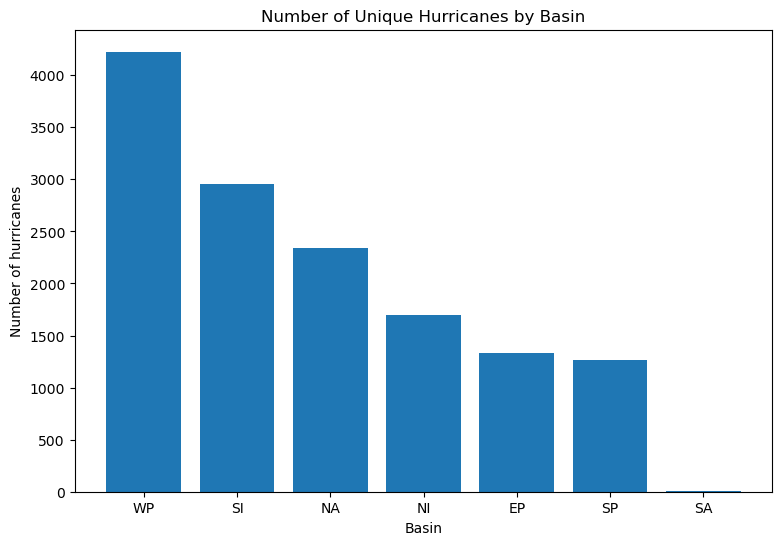

In [164]:
plt.figure(figsize=(9,6))
plt.bar(count_unique.index,count_unique.values)
plt.xlabel('Basin')
plt.ylabel('Number of hurricanes')
plt.title('Number of Unique Hurricanes by Basin')

## 8) Make a hexbin of the location of datapoints in Latitude and Longitude

Text(0.5, 1.0, 'Hexbin of Hurricane Locations')

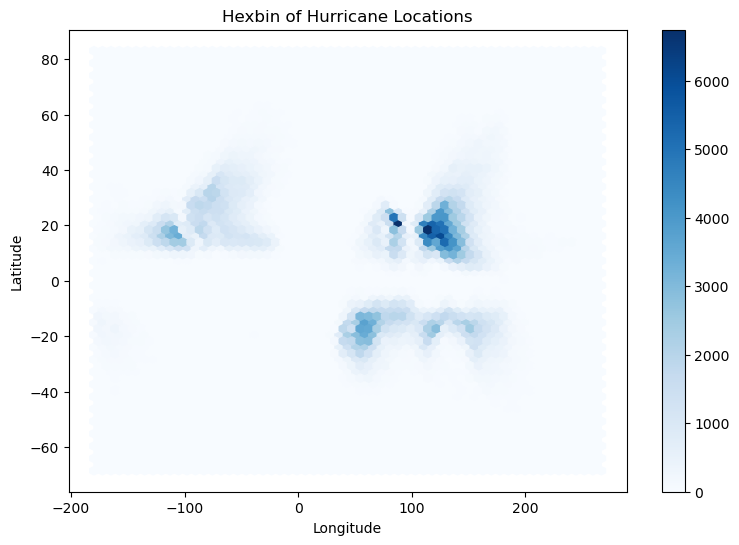

In [251]:
df_r.plot.hexbin('LON','LAT',gridsize=60,cmap='Blues',figsize=(9,6))
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Hexbin of Hurricane Locations')

## 9) Find Hurricane Katrina (from 2005) and plot its track as a scatter plot
First find the SID of this hurricane.

Next get this hurricane’s group and plot its position as a scatter plot. Use wind speed to color the points.

In [232]:
df_K= df_r[(df_r['NAME']== 'Katrina') & (df_r['SEASON']== 2005)]
df_K

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
597419,2004243S03088,2005,66,SI,MM,Katrina,2004-08-30 06:00:00,NR,-2.8000,87.7000,NaN,NaN
597420,2004243S03088,2005,66,SI,MM,Katrina,2004-08-30 09:00:00,NR,-2.9500,87.7625,NaN,NaN
597421,2004243S03088,2005,66,SI,MM,Katrina,2004-08-30 12:00:00,NR,-3.1000,87.8000,NaN,NaN
597422,2004243S03088,2005,66,SI,MM,Katrina,2004-08-30 15:00:00,NR,-3.2500,87.8000,NaN,NaN
597423,2004243S03088,2005,66,SI,MM,Katrina,2004-08-30 18:00:00,NR,-3.4000,87.8000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
606911,2005364N24324,2005,115,NA,NA,Katrina,2006-01-07 06:00:00,DS,24.2000,-52.7000,25.0,1012.0
606912,2005364N24324,2005,115,NA,NA,Katrina,2006-01-07 09:00:00,DS,24.4249,-53.4364,NaN,NaN
606913,2005364N24324,2005,115,NA,NA,Katrina,2006-01-07 12:00:00,DS,24.8000,-54.2000,25.0,1014.0
606914,2005364N24324,2005,115,NA,NA,Katrina,2006-01-07 15:00:00,DS,25.4631,-54.9521,NaN,NaN


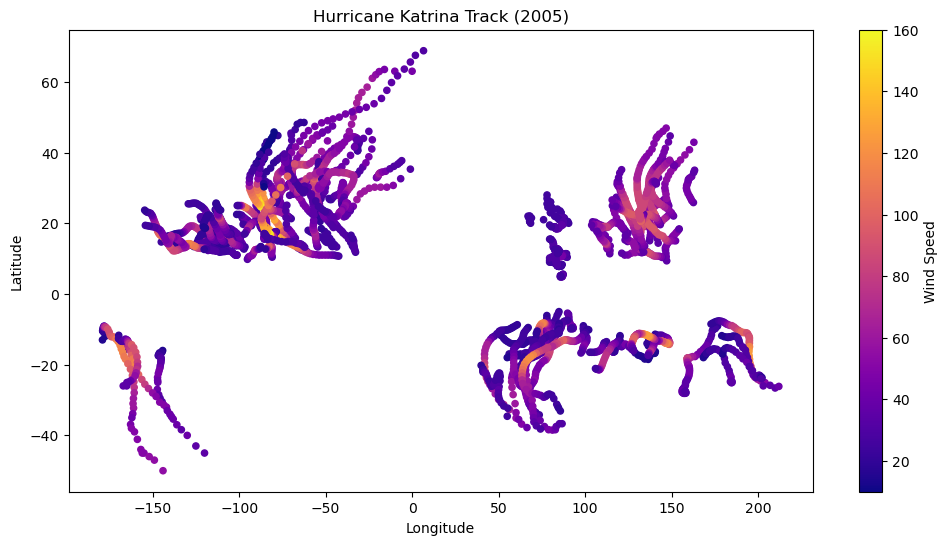

In [250]:
plt.figure(figsize=(12,6))
ktrack= plt.scatter(df_K['LON'],df_K['LAT'],c=df_K['WIND'],cmap='plasma',s=20)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Hurricane Katrina Track (2005)')
plt.colorbar(ktrack, label='Wind Speed') 

## 10) Make time the index on your dataframe

In [259]:
df_t = df_r.set_index('ISO_TIME' ).sort_index()
df_t

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,WIND,PRES
ISO_TIME,,,,,,,,,,,
1842-10-25 03:00:00,1842298N11080,1842,1,NI,BB,Katrina,NR,10.9000,80.3000,NaN,NaN
1842-10-25 06:00:00,1842298N11080,1842,1,NI,BB,Katrina,NR,10.8709,79.8265,NaN,NaN
1842-10-25 09:00:00,1842298N11080,1842,1,NI,BB,Katrina,NR,10.8431,79.3524,NaN,NaN
1842-10-25 12:00:00,1842298N11080,1842,1,NI,BB,Katrina,NR,10.8188,78.8772,NaN,NaN
1842-10-25 15:00:00,1842298N11080,1842,1,NI,BB,Katrina,NR,10.8000,78.4000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2024-05-27 15:00:00,2024147N19089,2024,27,NI,BB,Katrina,NR,23.9143,90.1400,NaN,NaN
2024-05-27 18:00:00,2024147N19089,2024,27,NI,BB,Katrina,NR,24.2000,90.4000,NaN,NaN
2024-05-27 18:00:00,2024146N11126,2024,26,WP,MM,Katrina,NR,17.6000,124.4000,NaN,NaN


## 11) Plot the count of all datapoints per year as a timeseries

You should use resample https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html

Which years stand out as having anomalous hurricane activity?

In [274]:
year_count = df_t.resample('Y').size()

/tmp/ipykernel_486800/3069618423.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  year_count = df_t.resample('Y').size()


In [266]:
year_count

ISO_TIME
1842-12-31      65
1843-12-31       0
1844-12-31       0
1845-12-31      25
1846-12-31       0
              ... 
2020-12-31    6407
2021-12-31    6493
2022-12-31    4439
2023-12-31    4720
2024-12-31     899
Freq: YE-DEC, Length: 183, dtype: int64

Text(0.5, 1.0, 'Datapoints per Year')

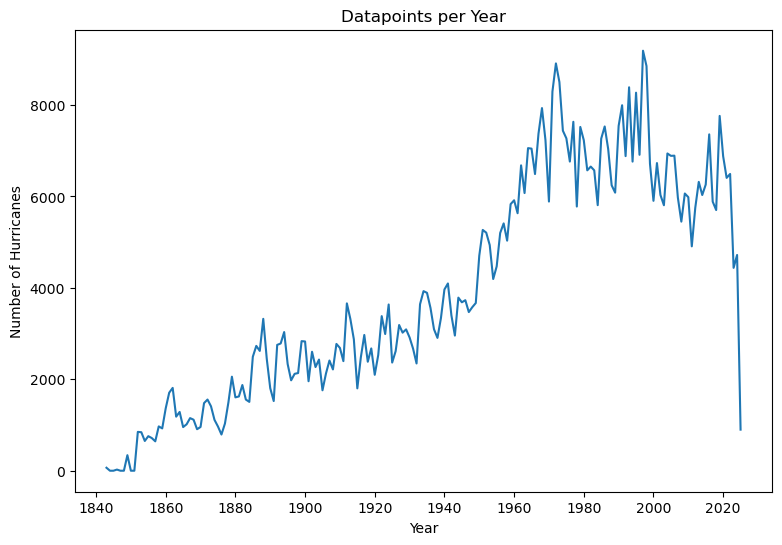

In [271]:
plt.figure(figsize=(9,6))
plt.plot(year_count.index,year_count.values)
plt.xlabel('Year')
plt.ylabel('Number of Hurricanes')
plt.title('Datapoints per Year')

In [280]:
year_count.idxmax()

Timestamp('1996-12-31 00:00:00')

In [281]:
year_count.max()

9189

In [282]:
year_count[year_count == 9189]

ISO_TIME
1996-12-31    9189
Freq: YE-DEC, dtype: int64

#### Which years stand out as having anomalous hurricane activity?
From 1840 to 1970, hurricane activity showed a general upward trend. However, from 1970 to 1995, the trend fluctuated significantly. In 1996, the number of hurricanes reached its peak, followed by a downward trend. Notably, from 2022 to 2024, the number of hurricanes experienced a sharp decline.